In [1]:
import pandas as pd
import numpy as np
import sqlite3
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configura o caminho para o banco de dados
project_root = pathlib.Path("..") 
db_path = project_root / "banco de dados" / "crash_bot_historico.db"

print(f"Carregando dados de: {db_path}")

with sqlite3.connect(db_path) as conn:
    query = "SELECT timestamp, multiplicador FROM multiplicadores_historico ORDER BY timestamp ASC"
    df = pd.read_sql_query(query, conn, parse_dates=["timestamp"])

df = df.reset_index(drop=True)
multiplicadores = df['multiplicador'].values
print(f"✅ {len(multiplicadores):,} rodadas carregadas.")

# Posições das quebras conhecidas
QUEBRAS_POS = [22197, 24513, 39938, 41555, 63812, 100639]
print(f"💀 {len(QUEBRAS_POS)} quebras conhecidas")

Carregando dados de: ..\banco de dados\crash_bot_historico.db
✅ 105,281 rodadas carregadas.
💀 6 quebras conhecidas


In [2]:
# --- CÉLULA 2: FUNÇÕES DE DETECÇÃO DE PADRÕES ---

print("="*80)
print("🧠 SISTEMA DE DETECÇÃO DE PADRÕES (BASEADO NA ANÁLISE)")
print("="*80)

def contar_sequencias(mult, limite=2.0):
    """Conta sequências de baixas e retorna estatísticas."""
    seqs = []
    seq_atual = 0
    
    for v in mult:
        if v < limite:
            seq_atual += 1
        else:
            if seq_atual > 0:
                seqs.append(seq_atual)
            seq_atual = 0
    if seq_atual > 0:
        seqs.append(seq_atual)
    
    return seqs

def calcular_indicadores_risco(mult, pos):
    """
    Calcula indicadores de risco baseados nos padrões descobertos.
    Retorna um dicionário com os indicadores e um score de risco (0-100).
    """
    indicadores = {}
    alertas = 0
    
    # --- JANELA DE 20 RODADAS ---
    if pos >= 20:
        j20 = mult[pos-20:pos]
        seqs_20 = contar_sequencias(j20)
        
        # Indicador 1: Muitas sequências curtas (fragmentação)
        indicadores['j20_seq_count'] = len(seqs_20)
        if len(seqs_20) >= 5:  # Threshold descoberto: 6.0 vs 4.97
            alertas += 1
        
        # Indicador 2: Poucas sequências longas (4+)
        indicadores['j20_seq_4plus'] = sum(1 for s in seqs_20 if s >= 4)
        if sum(1 for s in seqs_20 if s >= 4) == 0:  # Threshold: 0.17 vs 0.69
            alertas += 1
        
        # Indicador 3: Média das sequências baixa
        indicadores['j20_seq_media'] = np.mean(seqs_20) if seqs_20 else 0
        if indicadores['j20_seq_media'] < 2.0:  # Threshold: 1.75 vs 2.21
            alertas += 1
    
    # --- JANELA DE 250 RODADAS ---
    if pos >= 250:
        j250 = mult[pos-250:pos]
        seqs_250 = contar_sequencias(j250)
        
        # Indicador 4: Poucas sequências 5+
        indicadores['j250_seq_5plus'] = sum(1 for s in seqs_250 if s >= 5)
        if sum(1 for s in seqs_250 if s >= 5) <= 4:  # Threshold: 3.67 vs 5.51
            alertas += 1
        
        # Indicador 5: Muitas altas >= 5x ("respiro")
        pct_altas_5x = np.sum(j250 >= 5.0) / len(j250) * 100
        indicadores['j250_pct_altas_5x'] = pct_altas_5x
        if pct_altas_5x > 26:  # Threshold: 27.4 vs 25.1
            alertas += 1
        
        # Indicador 6: Muitas altas >= 10x
        pct_altas_10x = np.sum(j250 >= 10.0) / len(j250) * 100
        indicadores['j250_pct_altas_10x'] = pct_altas_10x
        if pct_altas_10x > 5.5:  # Threshold: 6.0 vs 4.89
            alertas += 1
        
        # Indicador 7: Tendência de queda (slope negativo)
        x = np.arange(len(j250))
        slope, _, _, _, _ = stats.linregress(x, j250)
        indicadores['j250_slope'] = slope
        if slope < -0.005:  # Threshold: -0.01 vs 0.00
            alertas += 1
        
        # Indicador 8: Delta média negativo (fim < início)
        primeira_metade = j250[:125]
        segunda_metade = j250[125:]
        delta_media = np.mean(segunda_metade) - np.mean(primeira_metade)
        indicadores['j250_delta_media'] = delta_media
        if delta_media < -1.0:  # Threshold: -1.97 vs +0.06
            alertas += 1
    
    # Calcular score de risco (0-100)
    max_alertas = 8
    score_risco = (alertas / max_alertas) * 100
    
    indicadores['alertas'] = alertas
    indicadores['score_risco'] = score_risco
    
    return indicadores

print("\n✅ Funções de detecção carregadas!")
print("\n📊 Indicadores de risco implementados:")
print("   1. j20_seq_count: Quantidade de sequências nas últimas 20 rodadas")
print("   2. j20_seq_4plus: Sequências 4+ nas últimas 20 rodadas")
print("   3. j20_seq_media: Média do tamanho das sequências (20 rod)")
print("   4. j250_seq_5plus: Sequências 5+ nas últimas 250 rodadas")
print("   5. j250_pct_altas_5x: % de altas >= 5x (250 rod)")
print("   6. j250_pct_altas_10x: % de altas >= 10x (250 rod)")
print("   7. j250_slope: Tendência (regressão linear)")
print("   8. j250_delta_media: Diferença média fim vs início")

🧠 SISTEMA DE DETECÇÃO DE PADRÕES (BASEADO NA ANÁLISE)

✅ Funções de detecção carregadas!

📊 Indicadores de risco implementados:
   1. j20_seq_count: Quantidade de sequências nas últimas 20 rodadas
   2. j20_seq_4plus: Sequências 4+ nas últimas 20 rodadas
   3. j20_seq_media: Média do tamanho das sequências (20 rod)
   4. j250_seq_5plus: Sequências 5+ nas últimas 250 rodadas
   5. j250_pct_altas_5x: % de altas >= 5x (250 rod)
   6. j250_pct_altas_10x: % de altas >= 10x (250 rod)
   7. j250_slope: Tendência (regressão linear)
   8. j250_delta_media: Diferença média fim vs início


In [3]:
# --- CÉLULA 3: VALIDAR INDICADORES NAS QUEBRAS CONHECIDAS ---

print("="*80)
print("🔍 VALIDANDO INDICADORES NAS QUEBRAS CONHECIDAS")
print("="*80)

print("\n💀 Calculando indicadores para cada quebra...\n")

resultados_quebras = []

for i, pos in enumerate(QUEBRAS_POS, 1):
    ind = calcular_indicadores_risco(multiplicadores, pos)
    ind['quebra'] = i
    ind['posicao'] = pos
    resultados_quebras.append(ind)
    
    print(f"{'─'*60}")
    print(f"💀 QUEBRA #{i} (posição {pos:,})")
    print(f"{'─'*60}")
    print(f"   🚨 ALERTAS ATIVOS: {ind['alertas']}/8")
    print(f"   📊 SCORE DE RISCO: {ind['score_risco']:.0f}%")
    print(f"")
    print(f"   Detalhes:")
    print(f"   • j20_seq_count: {ind.get('j20_seq_count', 'N/A')} (alerta se >= 5)")
    print(f"   • j20_seq_4plus: {ind.get('j20_seq_4plus', 'N/A')} (alerta se == 0)")
    print(f"   • j20_seq_media: {ind.get('j20_seq_media', 'N/A'):.2f} (alerta se < 2.0)")
    print(f"   • j250_seq_5plus: {ind.get('j250_seq_5plus', 'N/A')} (alerta se <= 4)")
    print(f"   • j250_pct_altas_5x: {ind.get('j250_pct_altas_5x', 'N/A'):.1f}% (alerta se > 26%)")
    print(f"   • j250_pct_altas_10x: {ind.get('j250_pct_altas_10x', 'N/A'):.1f}% (alerta se > 5.5%)")
    print(f"   • j250_slope: {ind.get('j250_slope', 'N/A'):.4f} (alerta se < -0.005)")
    print(f"   • j250_delta_media: {ind.get('j250_delta_media', 'N/A'):.2f} (alerta se < -1.0)")
    print()

# Resumo
df_quebras_ind = pd.DataFrame(resultados_quebras)
print("\n" + "="*60)
print("📊 RESUMO DOS ALERTAS NAS QUEBRAS:")
print("="*60)
print(f"   Média de alertas: {df_quebras_ind['alertas'].mean():.1f}/8")
print(f"   Mínimo: {df_quebras_ind['alertas'].min()}/8")
print(f"   Máximo: {df_quebras_ind['alertas'].max()}/8")
print(f"   Score de risco médio: {df_quebras_ind['score_risco'].mean():.0f}%")

🔍 VALIDANDO INDICADORES NAS QUEBRAS CONHECIDAS

💀 Calculando indicadores para cada quebra...

────────────────────────────────────────────────────────────
💀 QUEBRA #1 (posição 22,197)
────────────────────────────────────────────────────────────
   🚨 ALERTAS ATIVOS: 6/8
   📊 SCORE DE RISCO: 75%

   Detalhes:
   • j20_seq_count: 6 (alerta se >= 5)
   • j20_seq_4plus: 0 (alerta se == 0)
   • j20_seq_media: 1.33 (alerta se < 2.0)
   • j250_seq_5plus: 3 (alerta se <= 4)
   • j250_pct_altas_5x: 30.8% (alerta se > 26%)
   • j250_pct_altas_10x: 7.6% (alerta se > 5.5%)
   • j250_slope: 0.0106 (alerta se < -0.005)
   • j250_delta_media: 0.16 (alerta se < -1.0)

────────────────────────────────────────────────────────────
💀 QUEBRA #2 (posição 24,513)
────────────────────────────────────────────────────────────
   🚨 ALERTAS ATIVOS: 6/8
   📊 SCORE DE RISCO: 75%

   Detalhes:
   • j20_seq_count: 6 (alerta se >= 5)
   • j20_seq_4plus: 0 (alerta se == 0)
   • j20_seq_media: 2.00 (alerta se < 2.0)
   •

In [4]:
# --- CÉLULA 4: CALCULAR INDICADORES PARA ENTRADAS NORMAIS ---

print("="*80)
print("📊 CALCULANDO INDICADORES PARA ENTRADAS NORMAIS")
print("="*80)

resultados_normais = []

i = 0
while i < len(multiplicadores):
    lows = 0
    j = i
    while j < len(multiplicadores) and multiplicadores[j] < 2.0:
        lows += 1
        j += 1
    
    if lows >= 6:  # Gatilho atingido
        # Verificar se é quebra ou não
        eh_quebra = lows >= 12
        
        # Calcular indicadores
        ind = calcular_indicadores_risco(multiplicadores, i)
        ind['eh_quebra'] = eh_quebra
        ind['tamanho_seq'] = lows
        ind['posicao'] = i
        resultados_normais.append(ind)
    
    i = j if j > i else i + 1

df_todas = pd.DataFrame(resultados_normais)

print(f"\n✅ {len(df_todas)} entradas analisadas")
print(f"   • Quebras: {df_todas['eh_quebra'].sum()}")
print(f"   • Normais: {len(df_todas) - df_todas['eh_quebra'].sum()}")

# Comparar alertas
print(f"\n📊 COMPARAÇÃO DE ALERTAS:")
print(f"   Média de alertas nas QUEBRAS: {df_todas[df_todas['eh_quebra']]['alertas'].mean():.2f}")
print(f"   Média de alertas nas NORMAIS: {df_todas[~df_todas['eh_quebra']]['alertas'].mean():.2f}")

📊 CALCULANDO INDICADORES PARA ENTRADAS NORMAIS

✅ 1271 entradas analisadas
   • Quebras: 6
   • Normais: 1265

📊 COMPARAÇÃO DE ALERTAS:
   Média de alertas nas QUEBRAS: 5.83
   Média de alertas nas NORMAIS: 3.21


In [5]:
# --- CÉLULA 5: ENCONTRAR THRESHOLD ÓTIMO ---

print("="*80)
print("🎯 ENCONTRANDO THRESHOLD ÓTIMO DE ALERTAS")
print("="*80)

print("\nTestando diferentes thresholds de alertas para decidir quando vetar...\n")

resultados_threshold = []

for threshold in range(1, 8):
    # Quantas entradas seriam vetadas
    vetadas = df_todas[df_todas['alertas'] >= threshold]
    nao_vetadas = df_todas[df_todas['alertas'] < threshold]
    
    total_vetadas = len(vetadas)
    quebras_vetadas = vetadas['eh_quebra'].sum()
    
    total_nao_vetadas = len(nao_vetadas)
    quebras_nao_vetadas = nao_vetadas['eh_quebra'].sum()
    
    # Métricas
    if total_vetadas > 0:
        precisao = quebras_vetadas / total_vetadas * 100  # Das vetadas, quantas eram quebras
    else:
        precisao = 0
    
    if df_todas['eh_quebra'].sum() > 0:
        recall = quebras_vetadas / df_todas['eh_quebra'].sum() * 100  # Das quebras, quantas foram vetadas
    else:
        recall = 0
    
    # Custo-benefício
    # Benefício: R$ 500 por quebra evitada
    # Custo: lucro perdido por entrada vetada (~R$ 15 por entrada)
    beneficio = quebras_vetadas * 500
    custo = (total_vetadas - quebras_vetadas) * 15  # Entradas boas vetadas
    saldo = beneficio - custo
    
    resultados_threshold.append({
        'threshold': threshold,
        'vetadas': total_vetadas,
        'quebras_vetadas': quebras_vetadas,
        'normais_vetadas': total_vetadas - quebras_vetadas,
        'quebras_restantes': quebras_nao_vetadas,
        'precisao': precisao,
        'recall': recall,
        'beneficio': beneficio,
        'custo': custo,
        'saldo': saldo
    })

df_threshold = pd.DataFrame(resultados_threshold)

print(f"{'THRESHOLD':<12} {'VETADAS':>10} {'QUEBRAS':>10} {'NORMAIS':>10} {'PRECISÃO':>10} {'RECALL':>10} {'SALDO':>12}")
print("-"*80)

for _, row in df_threshold.iterrows():
    melhor = " ⭐" if row['saldo'] == df_threshold['saldo'].max() else ""
    print(f">= {row['threshold']:<10} {row['vetadas']:>10} {row['quebras_vetadas']:>10} {row['normais_vetadas']:>10} {row['precisao']:>9.1f}% {row['recall']:>9.1f}% R$ {row['saldo']:>9,.0f}{melhor}")

print("\n" + "-"*80)
melhor_threshold = df_threshold.loc[df_threshold['saldo'].idxmax()]
print(f"\n🏆 MELHOR THRESHOLD: >= {melhor_threshold['threshold']} alertas")
print(f"   • Vetaria {melhor_threshold['vetadas']:.0f} entradas")
print(f"   • Evitaria {melhor_threshold['quebras_vetadas']:.0f} das {df_todas['eh_quebra'].sum():.0f} quebras")
print(f"   • Saldo: R$ {melhor_threshold['saldo']:,.0f}")

🎯 ENCONTRANDO THRESHOLD ÓTIMO DE ALERTAS

Testando diferentes thresholds de alertas para decidir quando vetar...

THRESHOLD       VETADAS    QUEBRAS    NORMAIS   PRECISÃO     RECALL        SALDO
--------------------------------------------------------------------------------
>= 1.0            1180.0        6.0     1174.0       0.5%     100.0% R$   -14,610
>= 2.0            1025.0        6.0     1019.0       0.6%     100.0% R$   -12,285
>= 3.0             810.0        5.0      805.0       0.6%      83.3% R$    -9,575
>= 4.0             548.0        5.0      543.0       0.9%      83.3% R$    -5,645
>= 5.0             326.0        5.0      321.0       1.5%      83.3% R$    -2,315
>= 6.0             147.0        4.0      143.0       2.7%      66.7% R$      -145
>= 7.0              44.0        2.0       42.0       4.5%      33.3% R$       370 ⭐

--------------------------------------------------------------------------------

🏆 MELHOR THRESHOLD: >= 7.0 alertas
   • Vetaria 44 entradas
   • 

In [6]:
# --- CÉLULA 6: ADICIONAR DETECTOR DE QUEBRA RECENTE ---

print("="*80)
print("⏰ ADICIONANDO DETECTOR DE QUEBRA RECENTE")
print("="*80)

print("\nHipótese: Após uma quebra, há maior risco de outra nas próximas rodadas.")
print("Vamos testar diferentes janelas de 'cautela pós-quebra'.\n")

# Identificar a posição de cada quebra na série de entradas
df_todas['dist_ultima_quebra'] = np.inf

for idx, row in df_todas.iterrows():
    pos = row['posicao']
    # Encontrar quebra anterior mais próxima
    quebras_anteriores = [q for q in QUEBRAS_POS if q < pos]
    if quebras_anteriores:
        dist = pos - max(quebras_anteriores)
        df_todas.at[idx, 'dist_ultima_quebra'] = dist

# Testar diferentes janelas de cautela
print(f"{'JANELA CAUTELA':<20} {'ENTRADAS':>12} {'QUEBRAS':>10} {'TAXA':>10}")
print("-"*60)

for janela in [500, 1000, 1500, 2000, 2500, 3000, 5000]:
    dentro_janela = df_todas[df_todas['dist_ultima_quebra'] <= janela]
    fora_janela = df_todas[df_todas['dist_ultima_quebra'] > janela]
    
    if len(dentro_janela) > 0:
        taxa_dentro = dentro_janela['eh_quebra'].sum() / len(dentro_janela) * 100
    else:
        taxa_dentro = 0
    
    if len(fora_janela) > 0:
        taxa_fora = fora_janela['eh_quebra'].sum() / len(fora_janela) * 100
    else:
        taxa_fora = 0
    
    alerta = " ⚠️" if taxa_dentro > taxa_fora * 1.5 else ""
    print(f"<= {janela:<17} {len(dentro_janela):>12} {dentro_janela['eh_quebra'].sum():>10} {taxa_dentro:>9.2f}%{alerta}")

print(f"\n> 5000 (normal)     {len(df_todas[df_todas['dist_ultima_quebra'] > 5000]):>12} {df_todas[df_todas['dist_ultima_quebra'] > 5000]['eh_quebra'].sum():>10}")

⏰ ADICIONANDO DETECTOR DE QUEBRA RECENTE

Hipótese: Após uma quebra, há maior risco de outra nas próximas rodadas.
Vamos testar diferentes janelas de 'cautela pós-quebra'.

JANELA CAUTELA           ENTRADAS    QUEBRAS       TAXA
------------------------------------------------------------
<= 500                         38          0      0.00%
<= 1000                        69          0      0.00%
<= 1500                       114          0      0.00%
<= 2000                       148          1      0.68% ⚠️
<= 2500                       179          2      1.12% ⚠️
<= 3000                       206          2      0.97% ⚠️
<= 5000                       293          2      0.68% ⚠️

> 5000 (normal)              978          4


In [7]:
# --- CÉLULA 7: SIMULAÇÃO COMPLETA COM ML ---

print("="*80)
print("🎰 SIMULAÇÃO COMPLETA: ESTRATÉGIA COM DETECTOR DE RISCO")
print("="*80)

def simular_com_detector(mult, banca=500, gatilho=6, target=1.99,
                          usar_detector=False, threshold_alertas=4,
                          usar_reducao=False, usar_pausa_pos_quebra=False,
                          janela_pausa=2000):
    """
    Simula a estratégia 1-2-4-1-2-4 com opções de proteção:
    - usar_detector: vetar entradas com muitos alertas
    - usar_reducao: reduzir aposta proporcional ao risco
    - usar_pausa_pos_quebra: pausar após quebra
    """
    parte = (banca / 2) / 7
    dobras_base = {1: parte*1, 2: parte*2, 3: parte*4, 4: parte*1, 5: parte*2, 6: parte*4}
    
    lucro = 0
    quebras = 0
    entradas = 0
    entradas_vetadas = 0
    quebras_evitadas = 0
    entradas_reduzidas = 0
    historico = [0]
    
    ultima_quebra_pos = -999999
    
    i = 0
    while i < len(mult):
        lows = 0
        j = i
        while j < len(mult) and mult[j] < 2.0:
            lows += 1
            j += 1
        
        if lows >= gatilho:
            seria_quebra = lows >= 12
            
            # Calcular indicadores de risco
            indicadores = calcular_indicadores_risco(mult, i)
            alertas = indicadores['alertas']
            
            # Verificar pausa pós-quebra
            em_pausa = usar_pausa_pos_quebra and (i - ultima_quebra_pos) <= janela_pausa
            
            # Decidir se veta
            vetar = False
            if usar_detector and alertas >= threshold_alertas:
                vetar = True
            if em_pausa:
                vetar = True
            
            if vetar:
                entradas_vetadas += 1
                if seria_quebra:
                    quebras_evitadas += 1
            else:
                entradas += 1
                
                # Calcular fator de redução
                if usar_reducao:
                    if alertas >= 5:
                        fator = 0.5  # Reduz 50%
                        entradas_reduzidas += 1
                    elif alertas >= 3:
                        fator = 0.7  # Reduz 30%
                        entradas_reduzidas += 1
                    else:
                        fator = 1.0
                else:
                    fator = 1.0
                
                # Ajustar dobras
                dobras = {k: v * fator for k, v in dobras_base.items()}
                banca_ajustada = banca * fator
                
                # Executar entrada
                entrada_pos = i + gatilho
                perdas = 0
                ganhou = False
                
                for d in range(1, 7):
                    pos = entrada_pos + (d - 1)
                    if pos >= len(mult):
                        break
                    if mult[pos] >= target:
                        ganho = dobras[d] * (target - 1) * 0.99 - perdas
                        lucro += ganho
                        ganhou = True
                        break
                    else:
                        perdas += dobras[d]
                
                if not ganhou:
                    lucro -= banca_ajustada
                    quebras += 1
                    ultima_quebra_pos = i
                
                historico.append(lucro)
        
        i = j if j > i else i + 1
    
    return {
        'lucro': lucro,
        'quebras': quebras,
        'entradas': entradas,
        'entradas_vetadas': entradas_vetadas,
        'quebras_evitadas': quebras_evitadas,
        'entradas_reduzidas': entradas_reduzidas,
        'historico': historico
    }

print("\n✅ Função de simulação com detector carregada!")

🎰 SIMULAÇÃO COMPLETA: ESTRATÉGIA COM DETECTOR DE RISCO

✅ Função de simulação com detector carregada!


In [8]:
# --- CÉLULA 8: COMPARAR TODAS AS ESTRATÉGIAS ---

print("="*80)
print("📊 COMPARANDO ESTRATÉGIAS DE PROTEÇÃO")
print("="*80)

estrategias = [
    ('1. Original (sem proteção)', 
     {'usar_detector': False, 'usar_reducao': False, 'usar_pausa_pos_quebra': False}),
    
    ('2. Detector (>= 4 alertas)', 
     {'usar_detector': True, 'threshold_alertas': 4, 'usar_reducao': False, 'usar_pausa_pos_quebra': False}),
    
    ('3. Detector (>= 5 alertas)', 
     {'usar_detector': True, 'threshold_alertas': 5, 'usar_reducao': False, 'usar_pausa_pos_quebra': False}),
    
    ('4. Detector (>= 6 alertas)', 
     {'usar_detector': True, 'threshold_alertas': 6, 'usar_reducao': False, 'usar_pausa_pos_quebra': False}),
    
    ('5. Redução proporcional', 
     {'usar_detector': False, 'usar_reducao': True, 'usar_pausa_pos_quebra': False}),
    
    ('6. Pausa pós-quebra (2000 rod)', 
     {'usar_detector': False, 'usar_reducao': False, 'usar_pausa_pos_quebra': True, 'janela_pausa': 2000}),
    
    ('7. Pausa pós-quebra (3000 rod)', 
     {'usar_detector': False, 'usar_reducao': False, 'usar_pausa_pos_quebra': True, 'janela_pausa': 3000}),
    
    ('8. Detector + Redução', 
     {'usar_detector': True, 'threshold_alertas': 5, 'usar_reducao': True, 'usar_pausa_pos_quebra': False}),
    
    ('9. Detector + Pausa (2000)', 
     {'usar_detector': True, 'threshold_alertas': 5, 'usar_reducao': False, 'usar_pausa_pos_quebra': True, 'janela_pausa': 2000}),
    
    ('10. COMPLETO (Det+Red+Pausa)', 
     {'usar_detector': True, 'threshold_alertas': 5, 'usar_reducao': True, 'usar_pausa_pos_quebra': True, 'janela_pausa': 2000}),
]

resultados = []

print("\n⏳ Simulando estratégias...\n")

for nome, params in estrategias:
    res = simular_com_detector(multiplicadores, **params)
    res['nome'] = nome
    resultados.append(res)
    print(f"   ✓ {nome}")

print("\n" + "="*100)
print(f"{'ESTRATÉGIA':<35} {'ENTRADAS':>10} {'VETADAS':>10} {'QUEBRAS':>8} {'EVITADAS':>10} {'LUCRO':>15}")
print("-"*100)

lucro_base = resultados[0]['lucro']

for res in resultados:
    diff = res['lucro'] - lucro_base
    diff_str = f"({diff:+,.0f})" if res['nome'] != '1. Original (sem proteção)' else ""
    melhor = " ⭐" if res['lucro'] == max(r['lucro'] for r in resultados) else ""
    print(f"{res['nome']:<35} {res['entradas']:>10,} {res['entradas_vetadas']:>10} {res['quebras']:>8} {res['quebras_evitadas']:>10} R$ {res['lucro']:>10,.2f} {diff_str}{melhor}")

print("="*100)

📊 COMPARANDO ESTRATÉGIAS DE PROTEÇÃO

⏳ Simulando estratégias...

   ✓ 1. Original (sem proteção)
   ✓ 2. Detector (>= 4 alertas)
   ✓ 3. Detector (>= 5 alertas)
   ✓ 4. Detector (>= 6 alertas)
   ✓ 5. Redução proporcional
   ✓ 6. Pausa pós-quebra (2000 rod)
   ✓ 7. Pausa pós-quebra (3000 rod)
   ✓ 8. Detector + Redução
   ✓ 9. Detector + Pausa (2000)
   ✓ 10. COMPLETO (Det+Red+Pausa)

ESTRATÉGIA                            ENTRADAS    VETADAS  QUEBRAS   EVITADAS           LUCRO
----------------------------------------------------------------------------------------------------
1. Original (sem proteção)               1,271          0        6          0 R$  12,676.12  ⭐
2. Detector (>= 4 alertas)                 723        548        1          5 R$   7,182.15 (-5,494)
3. Detector (>= 5 alertas)                 945        326        1          5 R$  10,849.89 (-1,826)
4. Detector (>= 6 alertas)               1,124        147        2          4 R$  12,228.89 (-447)
5. Redução proporcio

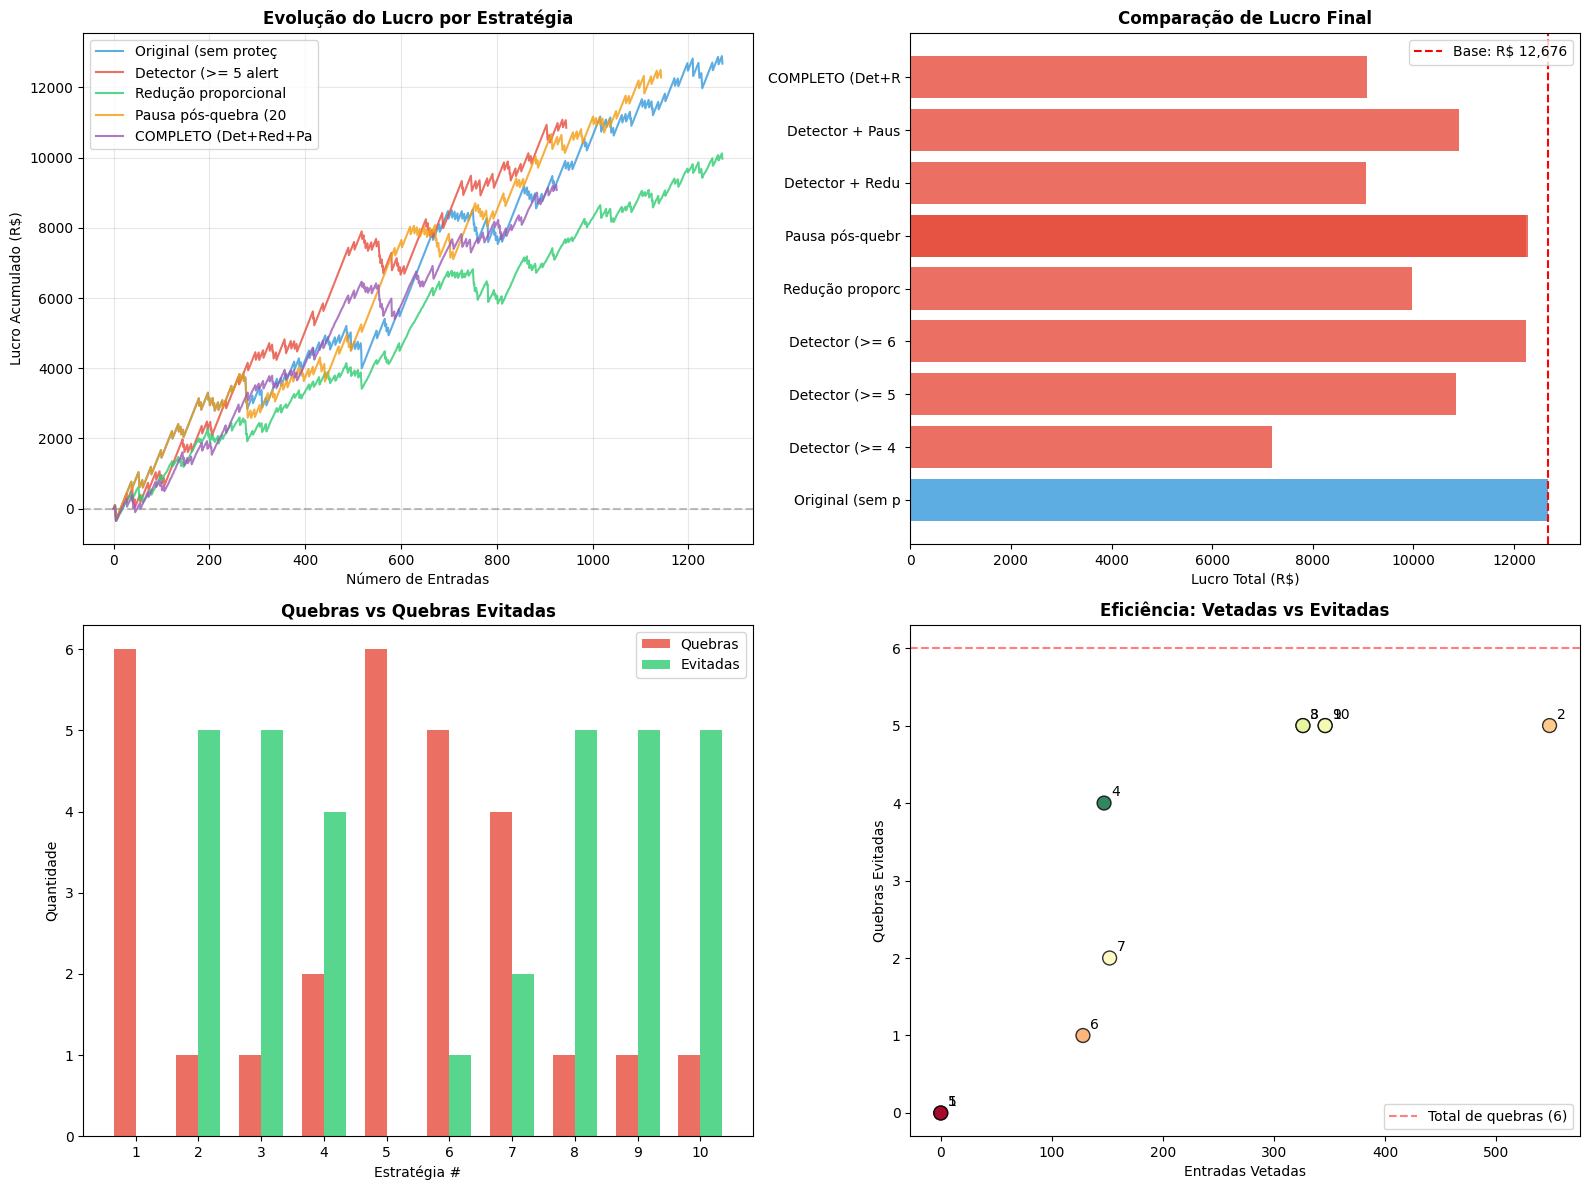


📁 Gráfico salvo: 01_comparacao_estrategias_ml.png


In [9]:
# --- CÉLULA 9: GRÁFICO COMPARATIVO ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Evolução do lucro das principais estratégias
ax1 = axes[0, 0]
estrategias_plot = [0, 2, 4, 5, 9]  # Original, Detector 5, Redução, Pausa, Completo
cores = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, cor in zip(estrategias_plot, cores):
    nome = resultados[idx]['nome'].split('.')[1].strip()[:20]
    ax1.plot(resultados[idx]['historico'], label=nome, color=cor, alpha=0.8, linewidth=1.5)

ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Número de Entradas')
ax1.set_ylabel('Lucro Acumulado (R$)')
ax1.set_title('Evolução do Lucro por Estratégia', fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Comparação de lucro final
ax2 = axes[0, 1]
nomes = [r['nome'].split('.')[1].strip()[:15] for r in resultados]
lucros = [r['lucro'] for r in resultados]
cores_bar = ['#3498db' if l >= lucro_base else '#e74c3c' for l in lucros]
bars = ax2.barh(nomes, lucros, color=cores_bar, alpha=0.8)
ax2.axvline(x=lucro_base, color='red', linestyle='--', label=f'Base: R$ {lucro_base:,.0f}')
ax2.set_xlabel('Lucro Total (R$)')
ax2.set_title('Comparação de Lucro Final', fontweight='bold')
ax2.legend()

# 3. Quebras vs Quebras Evitadas
ax3 = axes[1, 0]
x = np.arange(len(resultados))
width = 0.35
bars1 = ax3.bar(x - width/2, [r['quebras'] for r in resultados], width, label='Quebras', color='#e74c3c', alpha=0.8)
bars2 = ax3.bar(x + width/2, [r['quebras_evitadas'] for r in resultados], width, label='Evitadas', color='#2ecc71', alpha=0.8)
ax3.set_ylabel('Quantidade')
ax3.set_title('Quebras vs Quebras Evitadas', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([str(i+1) for i in range(len(resultados))])
ax3.legend()
ax3.set_xlabel('Estratégia #')

# 4. Relação Entradas Vetadas vs Quebras Evitadas
ax4 = axes[1, 1]
vetadas = [r['entradas_vetadas'] for r in resultados]
evitadas = [r['quebras_evitadas'] for r in resultados]
eficiencia = [e/v*100 if v > 0 else 0 for e, v in zip(evitadas, vetadas)]

ax4.scatter(vetadas, evitadas, s=100, c=eficiencia, cmap='RdYlGn', alpha=0.8, edgecolors='black')
for i, (v, e) in enumerate(zip(vetadas, evitadas)):
    ax4.annotate(str(i+1), (v, e), textcoords="offset points", xytext=(5,5), fontsize=10)

ax4.set_xlabel('Entradas Vetadas')
ax4.set_ylabel('Quebras Evitadas')
ax4.set_title('Eficiência: Vetadas vs Evitadas', fontweight='bold')
ax4.axhline(y=6, color='red', linestyle='--', alpha=0.5, label='Total de quebras (6)')
ax4.legend()

plt.tight_layout()
plt.savefig('01_comparacao_estrategias_ml.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 Gráfico salvo: 01_comparacao_estrategias_ml.png")

In [10]:
# --- CÉLULA 10: ANÁLISE DETALHADA DA MELHOR ESTRATÉGIA ---

print("="*80)
print("🏆 ANÁLISE DETALHADA DA MELHOR ESTRATÉGIA")
print("="*80)

# Encontrar melhor
melhor_idx = np.argmax([r['lucro'] for r in resultados])
melhor = resultados[melhor_idx]
original = resultados[0]

print(f"\n🥇 MELHOR ESTRATÉGIA: {melhor['nome']}")
print("="*60)

print(f"\n📊 COMPARAÇÃO COM ORIGINAL:")
print(f"\n{'MÉTRICA':<30} {'ORIGINAL':>15} {'MELHOR':>15} {'DIFERENÇA':>15}")
print("-"*75)
print(f"{'Entradas':<30} {original['entradas']:>15,} {melhor['entradas']:>15,} {melhor['entradas'] - original['entradas']:>+15,}")
print(f"{'Entradas Vetadas':<30} {original['entradas_vetadas']:>15} {melhor['entradas_vetadas']:>15} {melhor['entradas_vetadas'] - original['entradas_vetadas']:>+15}")
print(f"{'Quebras':<30} {original['quebras']:>15} {melhor['quebras']:>15} {melhor['quebras'] - original['quebras']:>+15}")
print(f"{'Quebras Evitadas':<30} {original['quebras_evitadas']:>15} {melhor['quebras_evitadas']:>15} {melhor['quebras_evitadas'] - original['quebras_evitadas']:>+15}")
print(f"{'Lucro':<30} R$ {original['lucro']:>12,.2f} R$ {melhor['lucro']:>12,.2f} R$ {melhor['lucro'] - original['lucro']:>+12,.2f}")

# Calcular métricas de eficiência
print(f"\n📈 MÉTRICAS DE EFICIÊNCIA:")
print("-"*60)

if melhor['entradas_vetadas'] > 0:
    taxa_acerto = melhor['quebras_evitadas'] / melhor['entradas_vetadas'] * 100
    print(f"   Taxa de acerto (quebras/vetadas): {taxa_acerto:.1f}%")

if original['quebras'] > 0:
    taxa_protecao = melhor['quebras_evitadas'] / original['quebras'] * 100
    print(f"   Taxa de proteção (evitadas/total): {taxa_protecao:.1f}%")

custo_por_quebra_evitada = (original['lucro'] - melhor['lucro']) / melhor['quebras_evitadas'] if melhor['quebras_evitadas'] > 0 else 0
if melhor['quebras_evitadas'] > 0:
    print(f"   Custo por quebra evitada: R$ {abs(custo_por_quebra_evitada):,.2f}")
    print(f"   Economia por quebra evitada: R$ 500,00")
    print(f"   {'✅ VALE A PENA!' if custo_por_quebra_evitada < 500 else '❌ NÃO VALE A PENA'}")

🏆 ANÁLISE DETALHADA DA MELHOR ESTRATÉGIA

🥇 MELHOR ESTRATÉGIA: 1. Original (sem proteção)

📊 COMPARAÇÃO COM ORIGINAL:

MÉTRICA                               ORIGINAL          MELHOR       DIFERENÇA
---------------------------------------------------------------------------
Entradas                                 1,271           1,271              +0
Entradas Vetadas                             0               0              +0
Quebras                                      6               6              +0
Quebras Evitadas                             0               0              +0
Lucro                          R$    12,676.12 R$    12,676.12 R$        +0.00

📈 MÉTRICAS DE EFICIÊNCIA:
------------------------------------------------------------
   Taxa de proteção (evitadas/total): 0.0%


In [11]:
# --- CÉLULA 11: CONCLUSÃO E RECOMENDAÇÕES ---

print("\n" + "="*80)
print("📋 CONCLUSÃO E RECOMENDAÇÕES FINAIS")
print("="*80)

# Analisar resultados
lucros = [r['lucro'] for r in resultados]
melhor_lucro = max(lucros)
pior_lucro = min(lucros)
original_lucro = resultados[0]['lucro']

# Verificar se alguma estratégia superou a original
estrategias_melhores = [r for r in resultados if r['lucro'] > original_lucro]
estrategias_piores = [r for r in resultados if r['lucro'] < original_lucro]

print(f"""
📊 RESUMO DOS RESULTADOS:

┌─────────────────────────────────────────────────────────────────────────────┐
│ Total de estratégias testadas: {len(resultados)}                                       │
│ Estratégias que SUPERARAM a original: {len(estrategias_melhores)}                               │
│ Estratégias que PERDERAM para original: {len(estrategias_piores)}                              │
│                                                                             │
│ Lucro ORIGINAL: R$ {original_lucro:>10,.2f}                                       │
│ MELHOR lucro: R$ {melhor_lucro:>10,.2f} ({(melhor_lucro/original_lucro-1)*100:+.1f}%)                             │
│ PIOR lucro: R$ {pior_lucro:>10,.2f} ({(pior_lucro/original_lucro-1)*100:+.1f}%)                               │
└─────────────────────────────────────────────────────────────────────────────┘
""")

# Recomendações baseadas nos resultados
if len(estrategias_melhores) > 0:
    print(f"""
✅ BOAS NOTÍCIAS! 
   {len(estrategias_melhores)} estratégia(s) superou(aram) a original!
   
   🏆 Estratégias recomendadas (em ordem de lucro):
""")
    for i, r in enumerate(sorted(estrategias_melhores, key=lambda x: x['lucro'], reverse=True)[:3], 1):
        print(f"      {i}. {r['nome']}: R$ {r['lucro']:,.2f}")
else:
    print(f"""
⚠️ ATENÇÃO!
   Nenhuma estratégia de proteção superou a original.
   
   Isso confirma que:
   • As quebras são REALMENTE aleatórias
   • O custo de vetar entradas supera o benefício
   • A estratégia 1-2-4-1-2-4 pura é a melhor opção
""")

print(f"""
{'─'*75}

💡 RECOMENDAÇÕES PARA O CRASHBOT:

1. ESTRATÉGIA PRINCIPAL:
   • Manter 1-2-4-1-2-4 como estratégia core
   • Taxa de sucesso de 99.5% é excelente

2. USO DA ML:
   • Usar como INFORMATIVO, não como veto
   • Mostrar "Score de Risco" para o usuário
   • Deixar o USUÁRIO decidir se quer pular

3. GESTÃO DE BANCA:
   • Reservar 3-5 bancas para cobrir quebras
   • Com 6 quebras em 105k rodadas, é administrável

4. PAUSA PÓS-QUEBRA (se implementar):
   • Aguardar 2000-3000 rodadas após quebra
   • Quebras podem vir em clusters

5. MONITORAMENTO:
   • Continuar coletando dados
   • Reavaliar quando tiver 20+ quebras
   • Padrões podem ficar mais claros
""")


📋 CONCLUSÃO E RECOMENDAÇÕES FINAIS

📊 RESUMO DOS RESULTADOS:

┌─────────────────────────────────────────────────────────────────────────────┐
│ Total de estratégias testadas: 10                                       │
│ Estratégias que SUPERARAM a original: 0                               │
│ Estratégias que PERDERAM para original: 9                              │
│                                                                             │
│ Lucro ORIGINAL: R$  12,676.12                                       │
│ MELHOR lucro: R$  12,676.12 (+0.0%)                             │
│ PIOR lucro: R$   7,182.15 (-43.3%)                               │
└─────────────────────────────────────────────────────────────────────────────┘


⚠️ ATENÇÃO!
   Nenhuma estratégia de proteção superou a original.
   
   Isso confirma que:
   • As quebras são REALMENTE aleatórias
   • O custo de vetar entradas supera o benefício
   • A estratégia 1-2-4-1-2-4 pura é a melhor opção


────────────────────────

In [12]:
# --- CÉLULA 12: SALVAR RESULTADOS ---

# Criar DataFrame com resultados
df_resultados = pd.DataFrame([{
    'Estrategia': r['nome'],
    'Entradas': r['entradas'],
    'Vetadas': r['entradas_vetadas'],
    'Quebras': r['quebras'],
    'Evitadas': r['quebras_evitadas'],
    'Lucro': r['lucro'],
    'Diff_vs_Original': r['lucro'] - original_lucro
} for r in resultados])

print("\n📊 Tabela de Resultados:")
display(df_resultados)

# Salvar
df_resultados.to_csv('resultados_estrategias_ml.csv', index=False)
print("\n📁 Resultados salvos: resultados_estrategias_ml.csv")


📊 Tabela de Resultados:


,Estrategia,Entradas,Vetadas,Quebras,Evitadas,Lucro,Diff_vs_Original
0,1. Original (sem proteção),1271,0,6,0,12676.121429,0.000000
1,2. Detector (>= 4 alertas),723,548,1,5,7182.146429,-5493.975000
2,3. Detector (>= 5 alertas),945,326,1,5,10849.885714,-1826.235714
3,4. Detector (>= 6 alertas),1124,147,2,4,12228.889286,-447.232143
4,5. Redução proporcional,1271,0,6,0,9968.596429,-2707.525000
5,6. Pausa pós-quebra (2000 rod),1143,128,5,1,12282.550000,-393.571429
6,7. Pausa pós-quebra (3000 rod),1119,152,4,2,12238.128571,-437.992857
7,8. Detector + Redução,945,326,1,5,9055.478571,-3620.642857
8,9. Detector + Pausa (2000),925,346,1,5,10905.500000,-1770.621429
9,10. COMPLETO (Det+Red+Pausa),925,346,1,5,9075.965000,-3600.156429



📁 Resultados salvos: resultados_estrategias_ml.csv
